In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from pathlib import Path
import xarray as xr

folder = Path("/Users/cjense/Desktop/phd/icesat/GLAH12_034-20260805_215149")
paths = sorted(folder.glob("*.H5"))

def load_icesat_file(path):
    dt = xr.open_datatree(path)

    elev_ds = dt["Data_40HZ/Elevation_Surfaces"].to_dataset()
    geo_ds = dt["Data_40HZ/Geolocation"].to_dataset()

    ds = xr.merge([geo_ds, elev_ds])

    ds = ds.assign_coords(
        lon=((ds["d_lon"] + 180) % 360) - 180,
        lat=ds["d_lat"],
        time=ds["DS_UTCTime_40"],
    )

    ds = ds.drop_vars(
        ["d_refRng", "d_lon", "d_lat", "d_IceSVar", "DS_DEMhiresArElv", "DS_UTCTime_40"],
        errors="ignore",
    )

    # Normalize the observation dimension so all files can be stacked
    obs_dim = ds["d_elev"].dims[0]
    if obs_dim != "point":
        ds = ds.rename({obs_dim: "point"})

    ds = ds.assign_coords(file=str(path.name))
    return ds

datasets = [load_icesat_file(p) for p in paths]
ds_all = xr.concat(
    datasets,
    dim="point",
    coords="minimal",
    compat="override",
    combine_attrs="override",
)

ds_all

KeyboardInterrupt: 

In [7]:
subset=ds_all.sel(
    lon=slice(xmin, xmax),
    lat=slice(ymin, ymax)
)

KeyError: 'Cannot get left slice bound for non-monotonic index with a missing label -25.820992. Either sort the index or specify an existing label.'

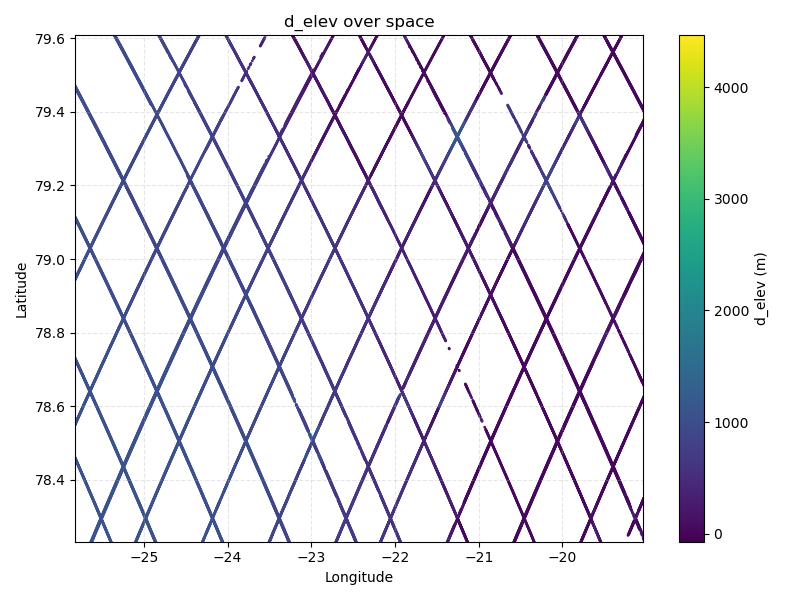

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ds_all["lon"],
    ds_all["lat"],
    c=ds_all["d_elev"],
    s=1,
    cmap="viridis",
)
xmin, ymin, xmax, ymax = [-25.820992, 78.232127, -19.035931, 79.607935]

plt.colorbar(label="d_elev (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("d_elev over space")
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
dt = xr.open_datatree('/Users/cjense/Desktop/phd/icesat/GLAH12_034-20260805_215149/GLAH12_634_2119_001_1303_0_01_0001.H5')
dt

<xarray.DataTree>
Group: /
│   Attributes: (12/82)
│       featureType:                        timeSeries
│       title:                              GLAS/ICESat L2 Global Antarctic and G...
│       comment:                            GLAH12 contains the ice sheet elevati...
│       summary:                            GLAH12 contains ice sheet elevation a...
│       license:                            http://nsidc.org/data/icesat/disclaim...
│       references:                         http://nsidc.org/data/docs/daac/glas_...
│       ...                                 ...
│       Range_Bias_Time:                    22:07:25
│       Timing_Bias_Date:                   2007-03-07
│       Timing_Bias_Time:                   22:07:25
│       identifier_product_doi:             10.5067/ICESAT/GLAS/DATA209
│       identifier_file_uuid:               c70e479f-e3dd-479c-84f5-5f47065d6b49
│       identifier_product_doi_authority:   http://dx.doi.org
├── Group: /Data_1HZ
│   │   Dimensions:       (DS_UTCTime_1: 8201)
│   │   Coordinates:
│   │     * DS_UTCTime_1  (DS_UTCTime_1) datetime64[ns] 66kB 2007-03-13T17:25:09.7488...
│   │   Attributes:
│   │       Description:  This group contain data with a rate of 1HZ. 1Hz data may be...
│   ├── Group: /Data_1HZ/Time
│   │       Dimensions:          (d_UTCTime_1: 8201)
│   │       Coordinates:
│   │         * d_UTCTime_1      (d_UTCTime_1) datetime64[ns] 66kB 2007-03-13T17:25:09.74...
│   │       Data variables:
│   │           i_rec_ndx        (d_UTCTime_1) int32 33kB ...
│   │           i_shot_count     (d_UTCTime_1) int32 33kB ...
│   │           d_transtime      (d_UTCTime_1) float64 66kB ...
│   │           d_deltagpstmcor  (d_UTCTime_1) float64 66kB ...
│   │           shot_time_flg    (d_UTCTime_1) int8 8kB ...
│   │           gps_time_flg     (d_UTCTime_1) int8 8kB ...
│   │           pl_timing_flg    (d_UTCTime_1) int8 8kB ...
│   │           ddelay_flg       (d_UTCTime_1) int8 8kB ...
│   │           peaktp_flg       (d_UTCTime_1) int8 8kB ...
│   │       Attributes:
│   │           Description:  This group contains the 1HZ index and time-related parameters
│   ├── Group: /Data_1HZ/Geolocation
│   │       Dimensions:       (DS_UTCTime_1: 8201)
│   │       Data variables:
│   │           d_lat         (DS_UTCTime_1) float64 66kB ...
│   │           d_lon         (DS_UTCTime_1) float64 66kB ...
│   │           i_track       (DS_UTCTime_1) int32 33kB ...
│   │       Attributes:
│   │           Description:  This group contains geolocation-related parameters.
│   ├── Group: /Data_1HZ/Quality
│   │       Dimensions:           (DS_UTCTime_1: 8201)
│   │       Data variables: (12/18)
│   │           orbit_pred_flg    (DS_UTCTime_1) int8 8kB ...
│   │           orbit_man_flg     (DS_UTCTime_1) int8 8kB ...
│   │           orbit_model_flg   (DS_UTCTime_1) int8 8kB ...
│   │           orbit_att_flg     (DS_UTCTime_1) int8 8kB ...
│   │           orbit_array_flg   (DS_UTCTime_1) int8 8kB ...
│   │           orbit_gps_flg     (DS_UTCTime_1) int8 8kB ...
│   │           ...                ...
│   │           att_gyro_flg      (DS_UTCTime_1) int8 8kB ...
│   │           att_lrs_flg       (DS_UTCTime_1) int8 8kB ...
│   │           altfrm_corr_flg   (DS_UTCTime_1) int8 8kB ...
│   │           altfrm_data_flg   (DS_UTCTime_1) int8 8kB ...
│   │           altfrm_meas_flg   (DS_UTCTime_1) int8 8kB ...
│   │           altfrm_use_flg    (DS_UTCTime_1) int8 8kB ...
│   │       Attributes:
│   │           Description:  This group contains quaility-related parameters and flags.
│   ├── Group: /Data_1HZ/Packet_data
│   │       Dimensions:          (DS_UTCTime_1: 8201)
│   │       Data variables: (12/29)
│   │           apid_ADLg_1_flg  (DS_UTCTime_1) int8 8kB ...
│   │           apid_ADLg_2_flg  (DS_UTCTime_1) int8 8kB ...
│   │           apid_ADLg_3_flg  (DS_UTCTime_1) int8 8kB ...
│   │           apid_ADLg_4_flg  (DS_UTCTime_1) int8 8kB ...
│   │           apid_ADSm_1_flg  (DS_UTCTime_1) int8 8kB ...
│  

In [ ]:
elev_ds = dt['Data_40HZ/Elevation_Surfaces']
elev_ds = elev_ds.to_dataset()
elev_ds

<xarray.Dataset> Size: 10MB
Dimensions:           (DS_UTCTime_40: 328040, DS_DEMhiresArElv: 9)
Coordinates:
  * DS_UTCTime_40     (DS_UTCTime_40) datetime64[ns] 3MB 2007-03-13T17:25:09....
  * DS_DEMhiresArElv  (DS_DEMhiresArElv) int32 36B 1 2 3 4 5 6 7 8 9
Data variables:
    d_elev            (DS_UTCTime_40) float64 3MB ...
    d_IceSVar         (DS_UTCTime_40) float64 3MB ...
    d_refRng          (DS_UTCTime_40) float64 3MB ...
Attributes:
    Description:  This group contains the surface-related parameters.

In [ ]:
geo_ds = dt['Data_40HZ/Geolocation']
geo_ds = geo_ds.to_dataset()
geo_ds

<xarray.Dataset> Size: 8MB
Dimensions:           (DS_UTCTime_40: 328040, DS_DEMhiresArElv: 9)
Coordinates:
  * DS_UTCTime_40     (DS_UTCTime_40) datetime64[ns] 3MB 2007-03-13T17:25:09....
  * DS_DEMhiresArElv  (DS_DEMhiresArElv) int32 36B 1 2 3 4 5 6 7 8 9
Data variables:
    d_lat             (DS_UTCTime_40) float64 3MB ...
    d_lon             (DS_UTCTime_40) float64 3MB ...
Attributes:
    Description:  This group contains geolocation-related parameters.

In [ ]:
ds = xr.merge([geo_ds, elev_ds])
ds = ds.assign_coords(
    {
        "lon":(ds['d_lon'] + 180) % 360 - 180,
        "lat":ds['d_lat'],
        "time":ds['DS_UTCTime_40']
    }
)
ds = ds.drop_vars(['d_refRng', 'd_lon', 'd_lat', 'd_IceSVar', 'DS_DEMhiresArElv', 'DS_UTCTime_40'])
ds

<xarray.Dataset> Size: 10MB
Dimensions:  (DS_UTCTime_40: 328040)
Coordinates:
    lon      (DS_UTCTime_40) float64 3MB -35.92 -35.93 -35.93 ... -52.0 -52.0
    lat      (DS_UTCTime_40) float64 3MB -76.42 -76.43 ... 1.798e+308 1.798e+308
    time     (DS_UTCTime_40) datetime64[ns] 3MB 2007-03-13T17:25:09.748864 .....
Dimensions without coordinates: DS_UTCTime_40
Data variables:
    d_elev   (DS_UTCTime_40) float64 3MB -9.01 -8.864 -9.308 ... nan nan nan
Attributes:
    Description:  This group contains geolocation-related parameters.

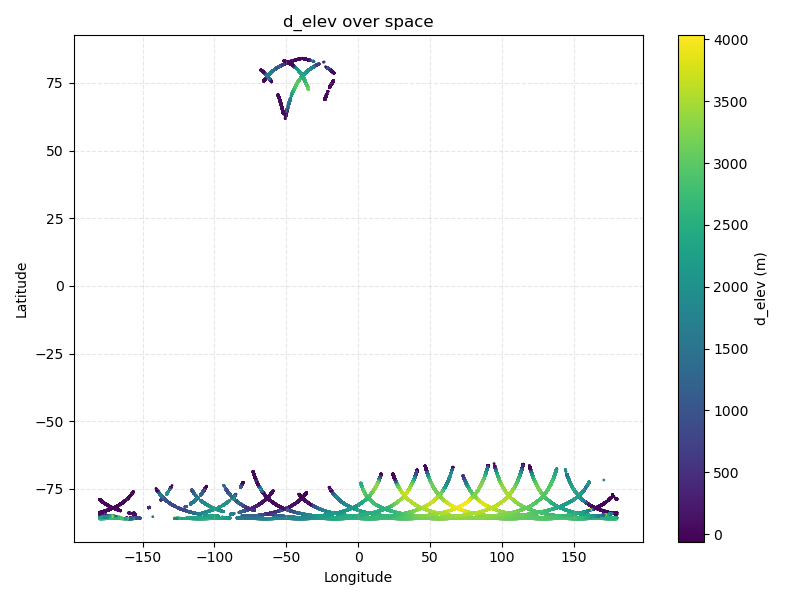

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ds["lon"],
    ds["lat"],
    c=ds["d_elev"],
    s=1,
    cmap="viridis",
)
xmin, ymin, xmax, ymax = [-25.820992, 78.232127, -19.035931, 79.607935]

plt.colorbar(label="d_elev (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("d_elev over space")
# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()